### Global Findex Dataset Thailand EDA 
Thailand's Financial and Digital Financial Inclusion: A Comparative Analysis of Global Findex 2021 and 2024

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set(style="whitegrid", context="notebook") 
plt.rcParams['figure.dpi'] = 100 
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 12)

df1 = pd.read_csv(
    'Findex Raw data_2021 (0521-0223).csv',
    encoding='latin1'
)

df2 = pd.read_csv(
    'Findex Raw Data_2025 (0524-1224).csv',
    encoding='latin1'
)
print(df1.shape)
print(df2.shape)

(143887, 128)
(144090, 199)


In [2]:

print(df1['year'].value_counts())

year
2021    127854
2022     16033
Name: count, dtype: int64


In [3]:
df1.head()

,economy,economycode,regionwb,pop_adult,wpid_random,wgt,...,remittances,mobileowner,internetaccess,anydigpayment,merchantpay_dig,year
0,Afghanistan,AFG,South Asia,22647496.0,144274031,0.716416,...,5.0,1,2,1,0.0,2021
1,Afghanistan,AFG,South Asia,22647496.0,180724554,0.497408,...,5.0,1,2,0,0.0,2021
2,Afghanistan,AFG,South Asia,22647496.0,130686682,0.650431,...,3.0,2,2,0,0.0,2021
3,Afghanistan,AFG,South Asia,22647496.0,142646649,0.991862,...,5.0,1,2,0,0.0,2021
4,Afghanistan,AFG,South Asia,22647496.0,199055310,0.554940,...,5.0,2,2,0,0.0,2021


In [4]:
df2.head()

,year,economy,economycode,regionwb,pop_adult,wpid_random,...,fin49c,fin49d,fin49e,fin49f,fin50,fin51
0,2024,Nicaragua,NIC,Latin America & Caribbean (excluding high income),4830854,111111345,...,NaN,NaN,NaN,NaN,NaN,NaN
1,2024,Costa Rica,CRI,Latin America & Caribbean (excluding high income),4118576,111111579,...,NaN,NaN,NaN,NaN,NaN,NaN
2,2024,Mali,MLI,Sub-Saharan Africa (excluding high income),12725942,111112511,...,NaN,NaN,NaN,NaN,NaN,NaN
3,2024,Kuwait,KWT,High income,3950546,111113432,...,NaN,NaN,NaN,NaN,1.0,1.0
4,2024,Turkiye,TUR,Europe & Central Asia (excluding high income),66691005,111115194,...,NaN,NaN,NaN,NaN,1.0,2.0


### EDA for Findex_dataset Thailand 2021 and 2024

In [5]:
print(df1.columns.to_list())
print(df2.columns.to_list()) 

['economy', 'economycode', 'regionwb', 'pop_adult', 'wpid_random', 'wgt', 'female', 'age', 'educ', 'inc_q', 'emp_in', 'urbanicity_f2f', 'account', 'account_fin', 'account_mob', 'fin1_1a', 'fin1_1b', 'fin2', 'fin4', 'fin4a', 'fin5', 'fin6', 'fin7', 'fin8', 'fin8a', 'fin8b', 'fin9', 'fin9a', 'fin10', 'fin10_1a', 'fin10_1b', 'fin10_1c', 'fin10_1d', 'fin10_1e', 'fin10a', 'fin10b', 'fin11_1', 'fin11a', 'fin11b', 'fin11c', 'fin11d', 'fin11e', 'fin11f', 'fin11g', 'fin11h', 'fin13_1a', 'fin13_1b', 'fin13_1c', 'fin13_1d', 'fin13_1e', 'fin13_1f', 'fin13a', 'fin13b', 'fin13c', 'fin13d', 'fin14_1', 'fin14_2', 'fin14_2_China', 'fin14a', 'fin14a1', 'fin14b', 'fin14c', 'fin14c_2', 'fin14c_2_China', 'fin16', 'fin17a', 'fin17a1', 'fin17b', 'fin20', 'fin22a', 'fin22b', 'fin22c', 'fin24', 'fin24a', 'fin24b', 'fin26', 'fin27_1', 'fin27c1', 'fin27c2', 'fin28', 'fin29_1', 'fin29c1', 'fin29c2', 'fin30', 'fin31a', 'fin31b', 'fin31b1', 'fin31b1_China', 'fin31c', 'fin32', 'fin33', 'fin34a', 'fin34b', 'fin34d', 

In [2]:
# Select Thailand economic data from both datasets 
df1_thailand = df1[df1['economy'] == 'Thailand'].copy()
df2_thailand = df2[df2['economy'] == 'Thailand'].copy() 
print(df1_thailand.shape)
print(df2_thailand.shape)

(1017, 128)
(1000, 199)


In [3]:
print(df1_thailand['year'].value_counts())
print(df2_thailand['year'].value_counts())

year
2021    1017
Name: count, dtype: int64
year
2024    1000
Name: count, dtype: int64


In [4]:
print(set(df1_thailand.columns) - set(df2_thailand.columns))

{'fin42a', 'fin14c_2_China', 'fin10_1a', 'fin13_1c', 'fin44c', 'fin29c1', 'fin44a', 'fin31b1_China', 'urbanicity_f2f', 'receive_pension', 'fin27_1', 'fin44d', 'fin8a', 'fin11g', 'fin10a', 'remittances', 'fin8b', 'fin10_1e', 'fin29c2', 'fin4a', 'fin45_1', 'fin13_1a', 'fin14_1', 'fin14_2', 'fin29_1', 'fin13_1f', 'fin14c_2', 'fin43e', 'fin27c2', 'fin1_1b', 'fin34e', 'fin9', 'fin39e', 'fin26', 'mobileowner', 'fin10_1d', 'fin10_1c', 'fin45_1_China', 'fin13_1b', 'fin31b1', 'fin10_1b', 'fin13_1d', 'internetaccess', 'fin13_1e', 'fin10b', 'fin17a1', 'fin27c1', 'fin14_2_China', 'fin1_1a', 'fin44b', 'fin14a1', 'fin11h'}


In [5]:
print(set(df2_thailand.columns) - set(df1_thailand.columns))

{'con7', 'fin14e', 'fin17e', 'fin17d', 'con1', 'fin24d3', 'con20', 'con25', 'con30e', 'con16', 'fin22h', 'fin49a', 'fin44', 'con4', 'con24', 'con30c', 'fh2', 'fin48d', 'fin25e4', 'fin48e', 'fin13e', 'con12', 'con13', 'fin31d', 'con2g', 'fin17f', 'fin29', 'con30b', 'fh2a', 'fin34c', 'fin51', 'con30h', 'fin11_2', 'con30g', 'urbanicity', 'fin22g', 'fin19', 'fin36', 'con31c', 'con8', 'fin48a', 'con18', 'con19', 'con17', 'fin13f_1', 'fin49c', 'fin41a', 'con27', 'fin49f', 'con11', 'con2c', 'fin48c', 'fin25e1', 'fin3', 'con3', 'fin14d', 'fin11_0', 'con31e', 'fin49b', 'con30d', 'fin40', 'con6', 'con2b', 'fin22a_1', 'fh1', 'fin22d', 'fin50', 'fin18', 'con31g', 'fin23', 'fin24d1', 'fin49d', 'con22', 'fin25e3', 'con10', 'fin24c', 'fin47', 'con30f', 'con30a', 'fin9b', 'con26', 'fin21', 'fin24d2', 'fin22f', 'con31b', 'con21', 'fin13f', 'fin39c', 'fin43c', 'con31h', 'con2f', 'fin41', 'receive_pensions', 'fin15', 'fin49e', 'con14', 'con29', 'con15', 'con9', 'con2e', 'fin46', 'dig_account', 'fin22e', 

### Variables exist in both datasets

In [6]:
common_columns = list(set(df1.columns) & set(df2.columns)) 
print(len(common_columns))
print(common_columns)

76
['female', 'account_mob', 'fin31c', 'fin11_1', 'regionwb', 'fin24b', 'fin35', 'fin22a', 'fin39a', 'fin34a', 'wpid_random', 'fin13b', 'fin8', 'borrowed', 'fin42', 'fin14c', 'fin43d', 'pay_utilities', 'wgt', 'fin9a', 'fin31a', 'fin11a', 'saved', 'fin34d', 'fin32', 'fin28', 'fin13a', 'fin13d', 'fin31b', 'fin7', 'fin43a', 'fin11f', 'fin34b', 'receive_wages', 'fin39b', 'receive_transfers', 'fin39d', 'fin33', 'fin17b', 'fin14a', 'fin11c', 'fin24', 'year', 'fin22c', 'fin22b', 'fin38', 'emp_in', 'fin45', 'fin10', 'fin37', 'pop_adult', 'fin30', 'fin5', 'fin16', 'account', 'fin20', 'economycode', 'fin11e', 'age', 'fin24a', 'account_fin', 'educ', 'fin4', 'fin11d', 'fin2', 'fin13c', 'inc_q', 'fin43b', 'economy', 'merchantpay_dig', 'fin14b', 'receive_agriculture', 'fin6', 'anydigpayment', 'fin17a', 'fin11b']


In [7]:
df_thai = pd.concat([df1_thailand, df2_thailand], ignore_index=True, sort=False)
print(df_thai.shape)
print(df_thai['year'].value_counts())

(2017, 251)
year
2021    1017
2024    1000
Name: count, dtype: int64


In [12]:
df_thai.head(10)

,economy,economycode,regionwb,pop_adult,wpid_random,wgt,...,fin49c,fin49d,fin49e,fin49f,fin50,fin51
0,Thailand,THA,East Asia & Pacific (excluding high income),58246340.0,156981272,0.224081,...,NaN,NaN,NaN,NaN,NaN,NaN
1,Thailand,THA,East Asia & Pacific (excluding high income),58246340.0,195399987,0.526118,...,NaN,NaN,NaN,NaN,NaN,NaN
2,Thailand,THA,East Asia & Pacific (excluding high income),58246340.0,181150505,0.148891,...,NaN,NaN,NaN,NaN,NaN,NaN
3,Thailand,THA,East Asia & Pacific (excluding high income),58246340.0,190062572,0.353825,...,NaN,NaN,NaN,NaN,NaN,NaN
4,Thailand,THA,East Asia & Pacific (excluding high income),58246340.0,146919431,0.138057,...,NaN,NaN,NaN,NaN,NaN,NaN
5,Thailand,THA,East Asia & Pacific (excluding high income),58246340.0,187160212,2.193632,...,NaN,NaN,NaN,NaN,NaN,NaN
6,Thailand,THA,East Asia & Pacific (excluding high income),58246340.0,124034566,2.320584,...,NaN,NaN,NaN,NaN,NaN,NaN
7,Thailand,THA,East Asia & Pacific (excluding high income),58246340.0,199028113,0.377784,...,NaN,NaN,NaN,NaN,NaN,NaN
8,Thailand,THA,East Asia & Pacific (excluding high income),58246340.0,121307534,1.251779,...,NaN,NaN,NaN,NaN,NaN,NaN
9,Thailand,THA,East Asia & Pacific (excluding high income),58246340.0,184101152,0.302764,...,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df_common = df_thai[common_columns].copy()
print(df_common.shape)
print(df_common['year'].value_counts()) 

(2017, 76)
year
2021    1017
2024    1000
Name: count, dtype: int64


In [9]:
print(df_common.columns)

Index(['female', 'account_mob', 'fin31c', 'fin11_1', 'regionwb', 'fin24b',
       'fin35', 'fin22a', 'fin39a', 'fin34a', 'wpid_random', 'fin13b', 'fin8',
       'borrowed', 'fin42', 'fin14c', 'fin43d', 'pay_utilities', 'wgt',
       'fin9a', 'fin31a', 'fin11a', 'saved', 'fin34d', 'fin32', 'fin28',
       'fin13a', 'fin13d', 'fin31b', 'fin7', 'fin43a', 'fin11f', 'fin34b',
       'receive_wages', 'fin39b', 'receive_transfers', 'fin39d', 'fin33',
       'fin17b', 'fin14a', 'fin11c', 'fin24', 'year', 'fin22c', 'fin22b',
       'fin38', 'emp_in', 'fin45', 'fin10', 'fin37', 'pop_adult', 'fin30',
       'fin5', 'fin16', 'account', 'fin20', 'economycode', 'fin11e', 'age',
       'fin24a', 'account_fin', 'educ', 'fin4', 'fin11d', 'fin2', 'fin13c',
       'inc_q', 'fin43b', 'economy', 'merchantpay_dig', 'fin14b',
       'receive_agriculture', 'fin6', 'anydigpayment', 'fin17a', 'fin11b'],
      dtype='object')


### Renaming Columns

In [10]:
df_common_renamed = df_common.rename(columns={
        'merchantmerchantpay_dig': 'digital_merch_payment',
        'fin24a': 'emergency_fund_access',
        'fin9a':'received_acc_balance_info',
        'fin22c':'borrowed_from_savings_club',
        'borrowed':'borrowed_money',
        'fin28':'sent_domestic_remittance_account',
        'fin43b':'agri_payment_mobile',
        'fin24b':'emergency_fund_source',
        'fin20':'applied_for_mobile_loan',
        'wpid_random':'respondent_id',
        'fin31a':'utility_payment_bank',
        'fin6':'account_usage',
        'fin37':'received_goverment_transfer',
        'fin11f':'no_account_lack_of_trust',
        'fin11_1':'ever_had_bank_account',
        'saved':'saved_money',
        'fin16':'ever_had_mobile_money_account',
        'educ':'education_level',
        'fin45':'financial_health_indicator',
        'fin43a':'agri_payment_bank',
        'fin14c':'no_mobile_account_lack_documentation',
        'fin30':'made_utility_payment',
        'fin4':'debit_card_ownership',
        'wgt':'survey_weight',
        'fin31b':'utility_payment_mobile',
        'fin22a':'borrowed_from_formal_bank',
        'receive_transfers':'received_transfers',
        'fin38':'received_public_pension',
        'fin14b':'no_mobile_account_too_expensive',
        'fin17b':'saved_mobile_money',
        'account_fin':'financial_instituion_account',
        'fin11d':'no_account_insufficient_funds',
        'fin13c': 'mobile_money_usage',
        'fin5':'account_ownership', 'fin35':'high_withdrawal_fee_wages', 
        'fin13a':'mobile_money_activity',
        'year':'survey_year', 'fin24':'emergency_funds',
        'receive_agriculture':'received_agriculture_payment',
        'fin11b':'no_account_too_expensive',
        'fin34a':'wages_bank_account', 
        'fin34d':'wages_card',
        'regionwb':'world_bank_region',
        'fin33':'wage_payment_method',
        'pop_adult':'adult_population',
        'inc_q':'income_quintile',
        'fin32':'recieved_wages',
        'fin39d':'agriculture_payment_method',
        'fin14a':'no_mobile_agents_far',
        'anydigpayment':'any_digital_payment',
        'fin34b':'wages_mobile', 
        'fin7':'account_transaction_activity',
        'fin22b':'borrowed_from_family_friends',
        'fin11a':'no_account_distance',
        'fin11e':'no_account_family_member',
        'receive_wages':'received_wages',
        'fin2':'debit_card_ownership',
        'fin39b':'agricultural_payment_mobile',
        'fin43d':'agri_payment_card',
        'fin17a':'saved_bank',
        'fin11c':'no_account_documentation',
        'fin13b':'mobile_money_send_recieve',
        'emp_in':'employment_status',
        'fin31c':'utility_payment_cash',
        'fin42':'recieved_agricultural_payment',
        'account_mob':'mobile_money_account',
        'fin10':'credit_card_ownership',
        'fin8':'store_money_account',
        'fin39a':'agriculture_payment_account',
        'account':'account_ownership',
        'fin13d':'mobile_money_transaction',
        'pay_utilities':'utility_payment'})

In [11]:
# print(df_common_renamed.columns)
# df_common_renamed.head()
df_common_renamed.describe(include='all')

,female,mobile_money_account,utility_payment_cash,ever_had_bank_account,world_bank_region,emergency_fund_source,...,no_mobile_account_too_expensive,received_agriculture_payment,account_usage,any_digital_payment,saved_bank,no_account_too_expensive
count,2017.000000,2017.000000,232.000000,110.000000,2017,1891.000000,...,1017.000000,2017.000000,1854.000000,2017.000000,2017.000000,130.000000
unique,NaN,NaN,NaN,NaN,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,East Asia & Pacific (excluding high income),NaN,...,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,2017,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.454140,0.516113,1.038793,1.736364,NaN,2.620307,...,1.355949,3.645017,1.599245,0.888448,1.499256,1.923077
std,0.498016,0.499864,0.268480,0.762387,NaN,1.285116,...,0.527909,0.877924,0.938830,0.314892,0.581736,0.617765
min,1.000000,0.000000,1.000000,1.000000,NaN,1.000000,...,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
25%,1.000000,0.000000,1.000000,1.000000,NaN,2.000000,...,1.000000,4.000000,1.000000,1.000000,1.000000,2.000000
50%,1.000000,1.000000,1.000000,2.000000,NaN,3.000000,...,1.000000,4.000000,1.000000,1.000000,1.000000,2.000000
75%,2.000000,1.000000,1.000000,2.000000,NaN,3.000000,...,2.000000,4.000000,2.000000,1.000000,2.000000,2.000000


### Clearing special missing values

In [12]:
#check for missing values
print(df_common_renamed.isnull().sum())
print(df_common_renamed.isnull().mean())

female                             0
mobile_money_account               0
utility_payment_cash            1785
ever_had_bank_account           1907
world_bank_region                  0
                                ... 
received_agriculture_payment       0
account_usage                    163
any_digital_payment                0
saved_bank                         0
no_account_too_expensive        1887
Length: 76, dtype: int64
female                          0.000000
mobile_money_account            0.000000
utility_payment_cash            0.884978
ever_had_bank_account           0.945464
world_bank_region               0.000000
                                  ...   
received_agriculture_payment    0.000000
account_usage                   0.080813
any_digital_payment             0.000000
saved_bank                      0.000000
no_account_too_expensive        0.935548
Length: 76, dtype: float64


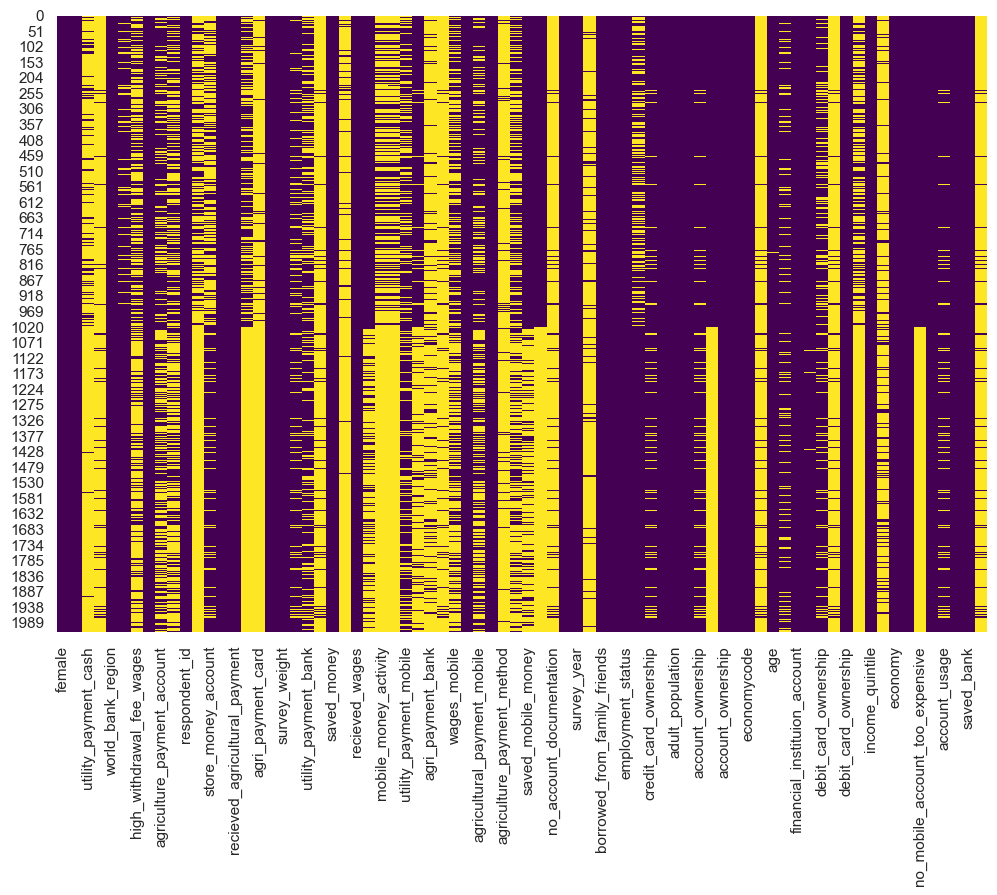

In [13]:
# visualize missing values
import seaborn as sns 
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
sns.heatmap(df_common_renamed.isnull(), cbar=False, cmap='viridis')
plt.show()

In [31]:
# !pip install missingno

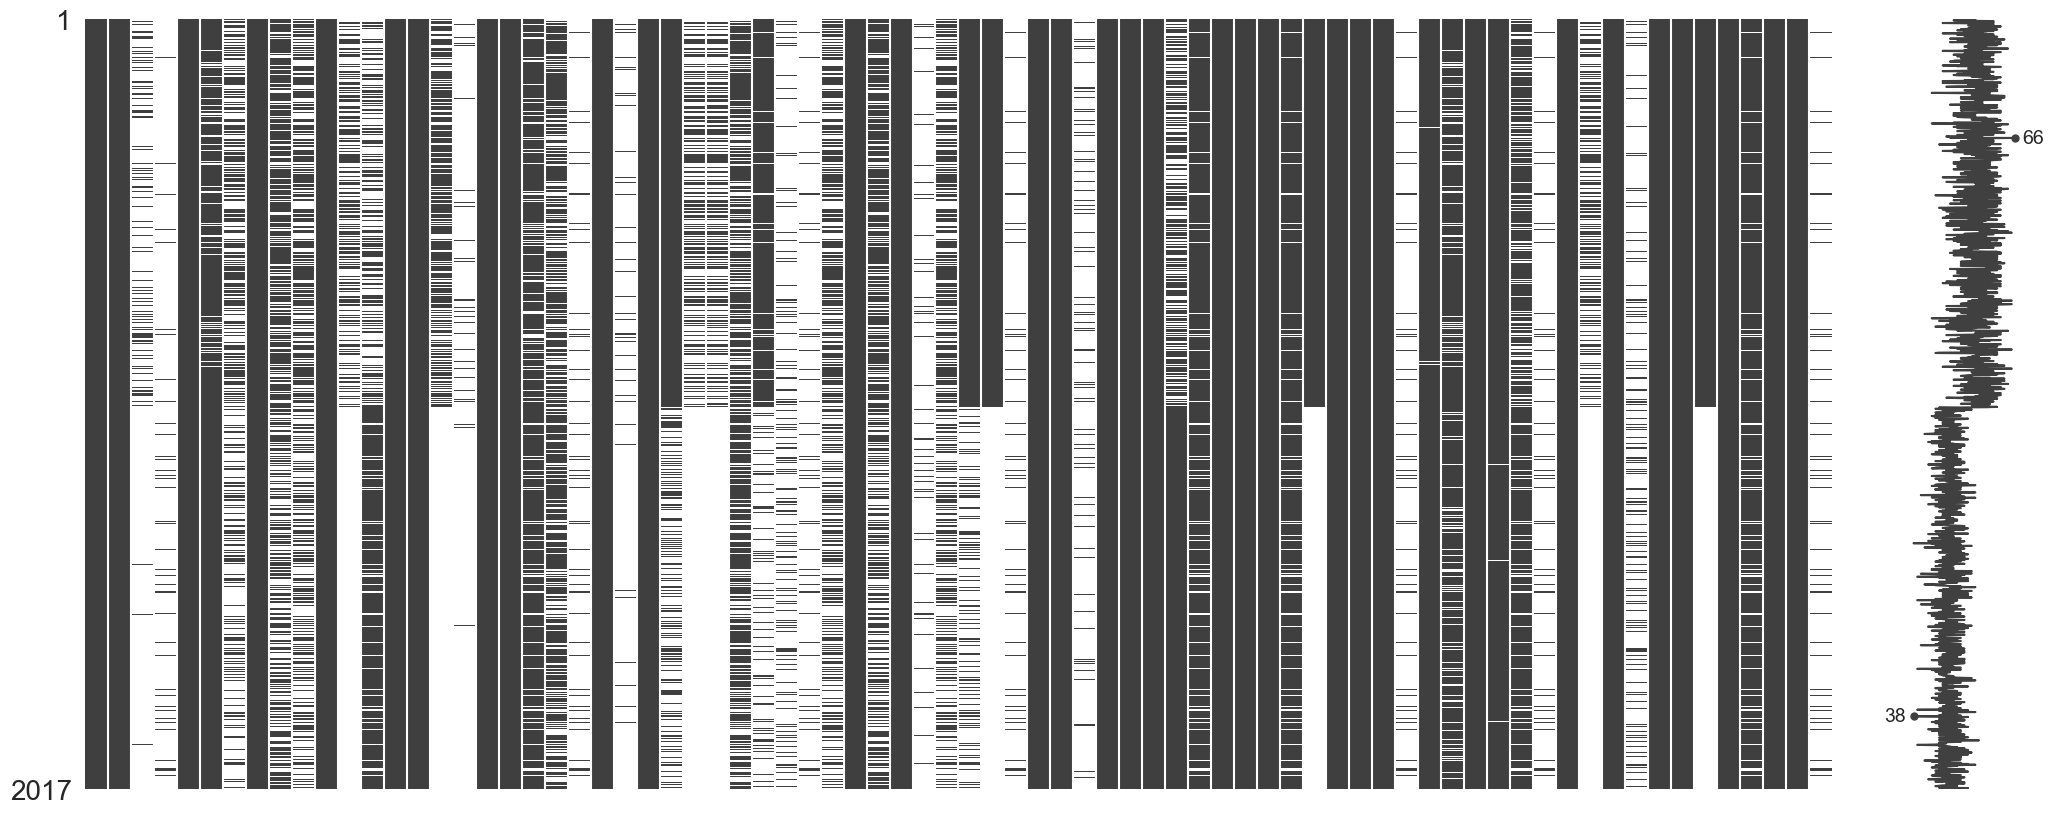

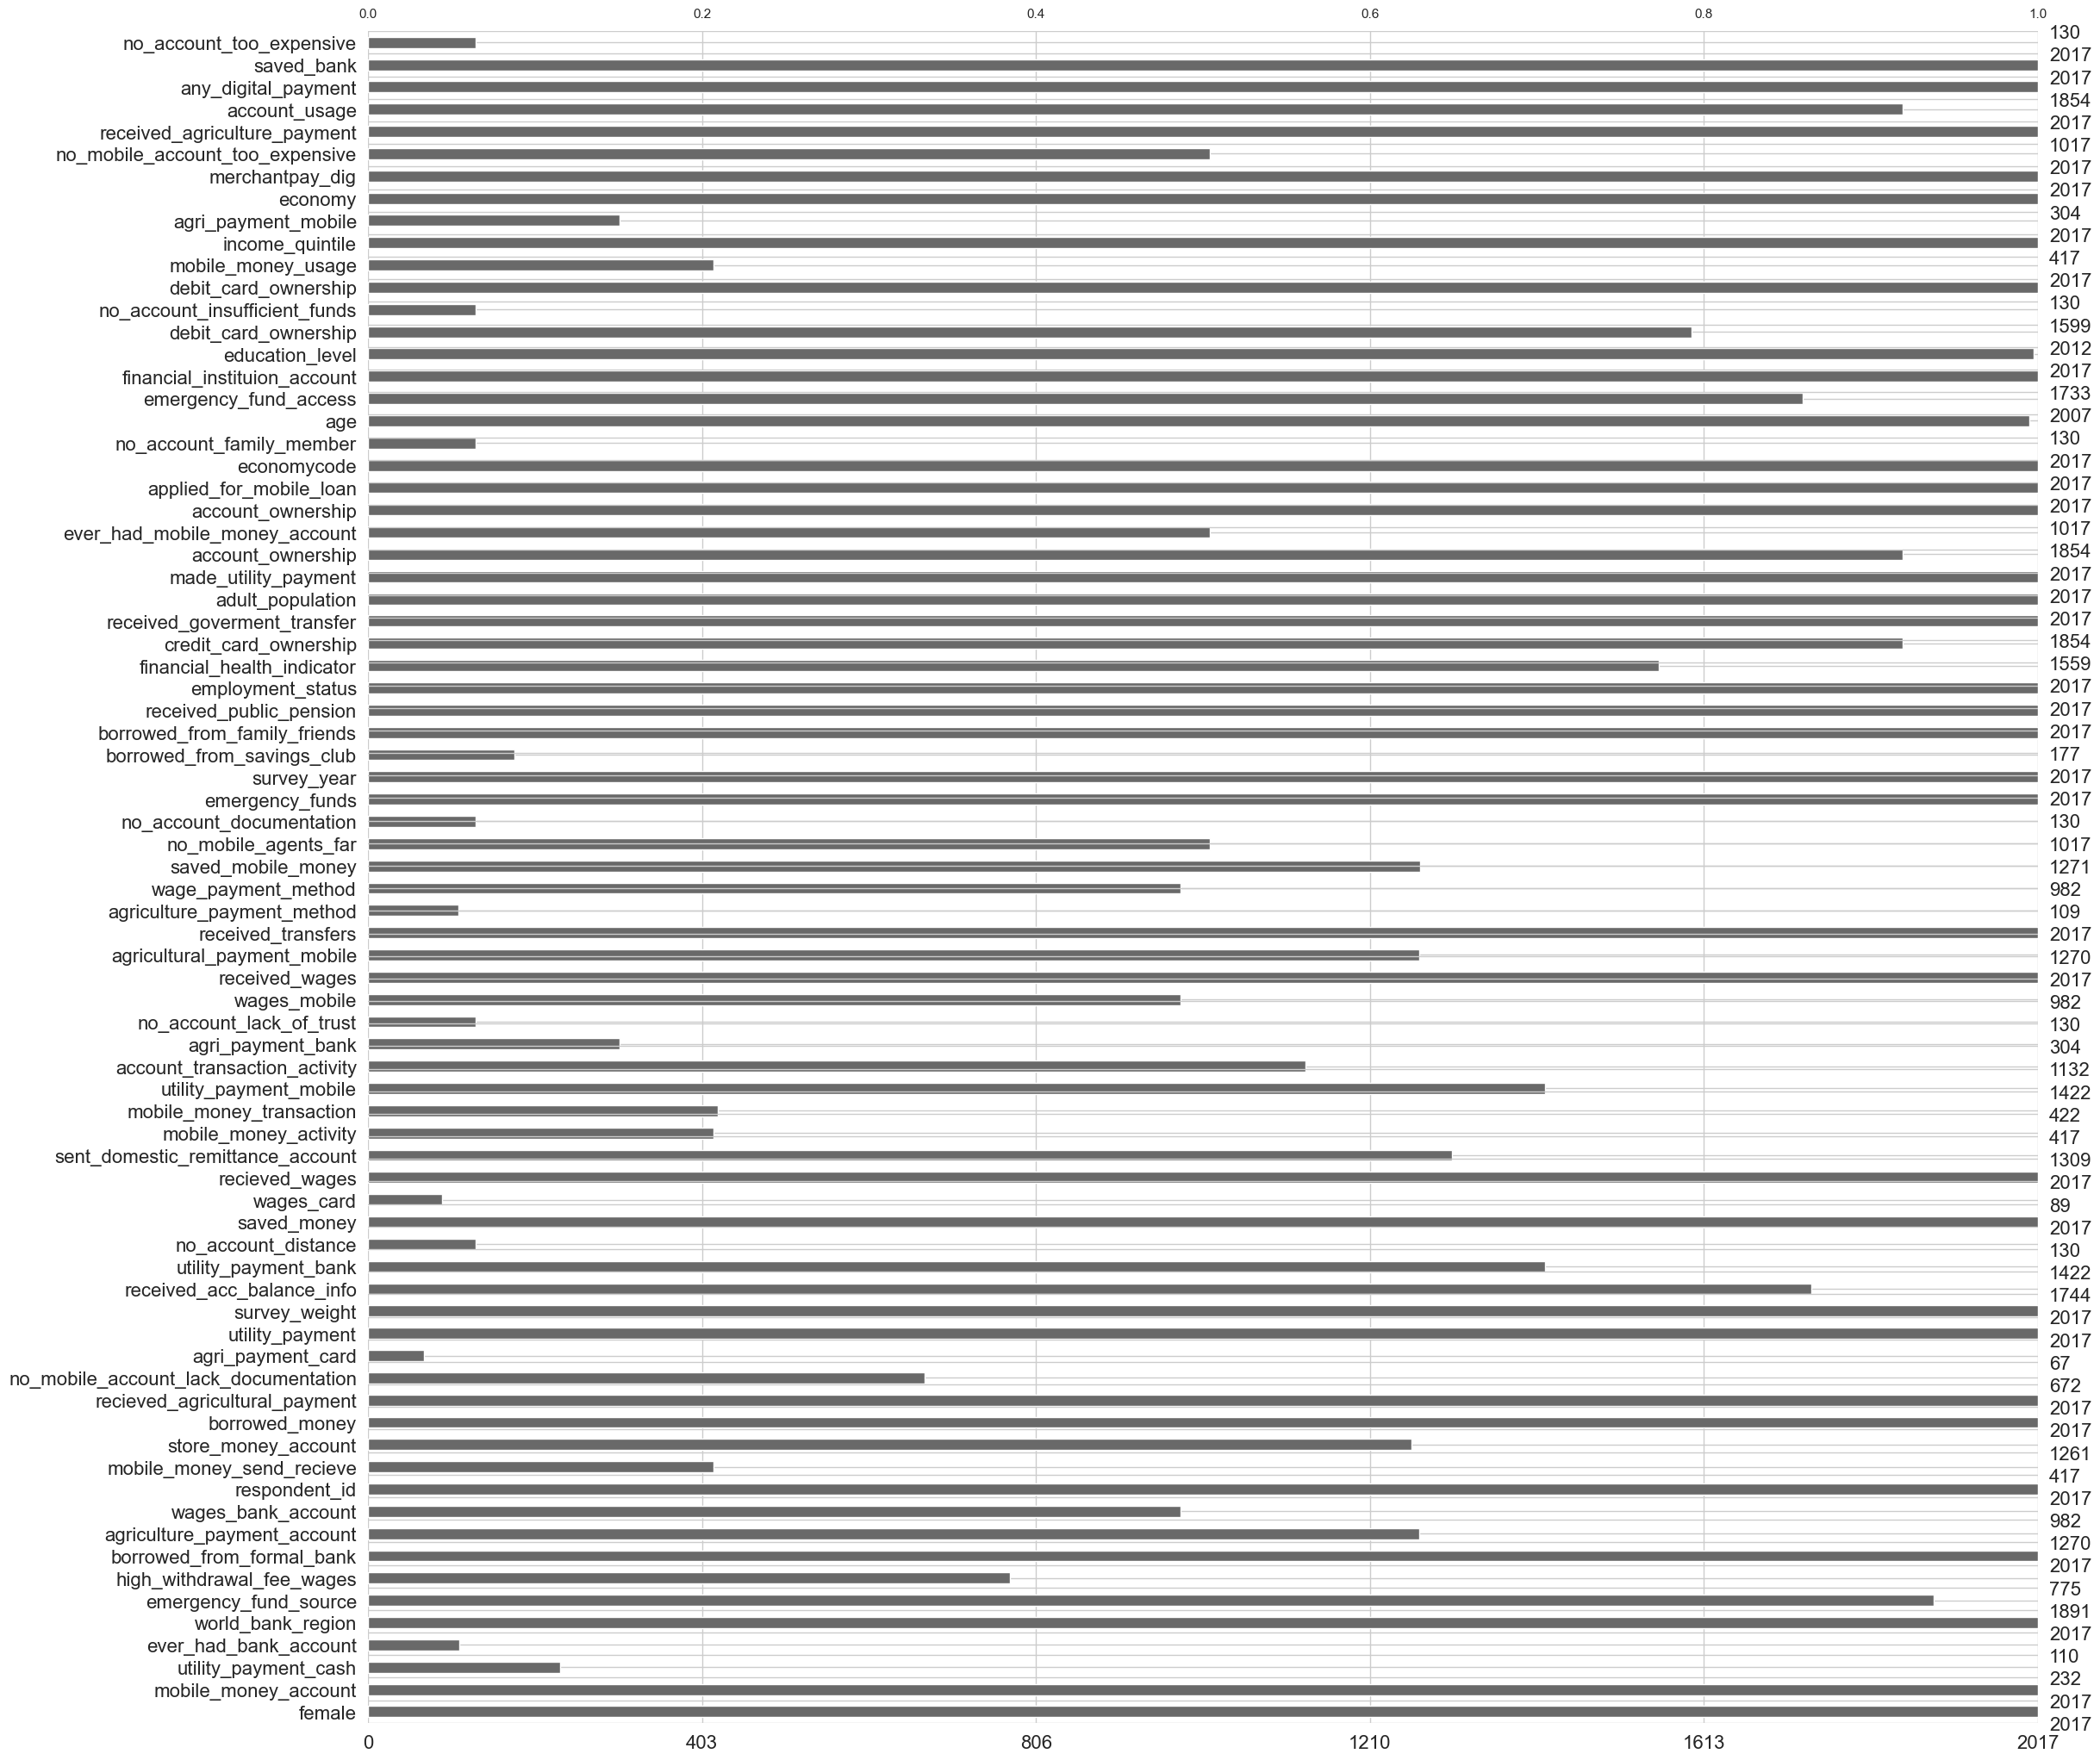

In [16]:
try:
    import missingno as msno
except ModuleNotFoundError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "missingno"])
    import missingno as msno
msno.matrix(df_common_renamed)
plt.show()
msno.bar(df_common_renamed)
plt.show()

In [ ]:
#Datasets often contain codes representing:
# Don't know # Refused # Not applicable # Miss 
codes_to_check = ["Don't know", "Refused", "Not applicable", "Miss"]
for code in codes_to_check:
    if code in df_common_renamed.values:
        print(f"Found code: {code}")
    else:
        print(f"Code not found: {code}")
print("Finished checking for codes.")

Code not found: Don't know
Code not found: Refused
Code not found: Not applicable
Code not found: Miss
Finished checking for codes.


In [18]:
df_common_renamed['codes_found'] = df_common_renamed.isin(codes_to_check).any(axis=1)
print(df_common_renamed['codes_found'].value_counts())
print("Number of rows with codes found:", df_common_renamed['codes_found'].sum())
print("Number of rows without codes found:", (~df_common_renamed['codes_found']).sum())

codes_found
False    2017
Name: count, dtype: int64
Number of rows with codes found: 0
Number of rows without codes found: 2017


In [19]:
df_common_renamed.columns.tolist()

['female',
 'mobile_money_account',
 'utility_payment_cash',
 'ever_had_bank_account',
 'world_bank_region',
 'emergency_fund_source',
 'high_withdrawal_fee_wages',
 'borrowed_from_formal_bank',
 'agriculture_payment_account',
 'wages_bank_account',
 'respondent_id',
 'mobile_money_send_recieve',
 'store_money_account',
 'borrowed_money',
 'recieved_agricultural_payment',
 'no_mobile_account_lack_documentation',
 'agri_payment_card',
 'utility_payment',
 'survey_weight',
 'received_acc_balance_info',
 'utility_payment_bank',
 'no_account_distance',
 'saved_money',
 'wages_card',
 'recieved_wages',
 'sent_domestic_remittance_account',
 'mobile_money_activity',
 'mobile_money_transaction',
 'utility_payment_mobile',
 'account_transaction_activity',
 'agri_payment_bank',
 'no_account_lack_of_trust',
 'wages_mobile',
 'received_wages',
 'agricultural_payment_mobile',
 'received_transfers',
 'agriculture_payment_method',
 'wage_payment_method',
 'saved_mobile_money',
 'no_mobile_agents_far'

In [22]:
print(df_common_renamed['female'].value_counts())
print(df_common_renamed['female'].dtype)

female
1    1101
2     916
Name: count, dtype: int64
int64


In [23]:
df_common_renamed["gender"] = df_common_renamed["female"].map({1:"Female", 2:"Male"})
print(df_common_renamed['gender'].value_counts())
print(df_common_renamed['gender'].dtype)

gender
Female    1101
Male       916
Name: count, dtype: int64
object


### Demographic dataset

In [15]:
demo_cols = ['year','economy','economycode', 
            'wgt', 'female', 'age', 'educ',
            'inc_q', 'emp_in'] 

# Demographic columns for analysis 
demo_df = df_common[demo_cols].copy()
print(demo_df.head())
print(demo_df.shape)

   year   economy economycode       wgt  female   age  educ  inc_q  emp_in
0  2021  Thailand         THA  0.224081       1  27.0   3.0    4.0     1.0
1  2021  Thailand         THA  0.526118       2  30.0   3.0    4.0     1.0
2  2021  Thailand         THA  0.148891       1  45.0   3.0    4.0     1.0
3  2021  Thailand         THA  0.353825       1  45.0   3.0    1.0     1.0
4  2021  Thailand         THA  0.138057       2  39.0   3.0    4.0     1.0
(2017, 9)


In [16]:
# check NaN values
print(demo_df.isna().sum())

year            0
economy         0
economycode     0
wgt             0
female          0
age            10
educ            5
inc_q           0
emp_in          0
dtype: int64


In [28]:
print(demo_df.groupby('year')['age'].apply(lambda x: x.isna().sum()))
print(demo_df.groupby('year')['educ'].apply(lambda x: x.isna().sum()))
print(demo_df.groupby('year')['inc_q'].apply(lambda x: x.isna().sum()))
print(demo_df.groupby('year')['emp_in'].apply(lambda x: x.isna().sum()))

year
2021    10
2024     0
Name: age, dtype: int64
year
2021    0
2024    5
Name: educ, dtype: int64
year
2021    0
2024    0
Name: inc_q, dtype: int64
year
2021    0
2024    0
Name: emp_in, dtype: int64


In [17]:
# convert variables to nullable integers 
demo_df['age'] = demo_df['age'].astype('Int64')
demo_df['educ'] = demo_df['educ'].astype('Int64')

In [18]:
demo_df['year'] = demo_df['year'].astype('int64')
demo_df['female_binary'] = (demo_df['female'] == 1).astype('Int64') 
demo_df['inc_q'] = demo_df['inc_q'].astype('Int64')
demo_df['emp_in'] = demo_df['emp_in'].astype('Int64') 
print(demo_df.dtypes)
print(demo_df.head())

year               int64
economy           object
economycode       object
wgt              float64
female             int64
age                Int64
educ               Int64
inc_q              Int64
emp_in             Int64
female_binary      Int64
dtype: object
   year   economy economycode       wgt  female  age  educ  inc_q  emp_in  \
0  2021  Thailand         THA  0.224081       1   27     3      4       1   
1  2021  Thailand         THA  0.526118       2   30     3      4       1   
2  2021  Thailand         THA  0.148891       1   45     3      4       1   
3  2021  Thailand         THA  0.353825       1   45     3      1       1   
4  2021  Thailand         THA  0.138057       2   39     3      4       1   

   female_binary  
0              1  
1              0  
2              1  
3              1  
4              0  


### Financial inclusion Dataset

In [ ]:
### Financial inclusion Dataset

finance_df = df_common[]